## EDA Movie Insigths

---

Este notebook presenta el análisis exploratorio del dataset de películas, utilizando clases desarrolladas en el proyecto para la carga y procesamiento de datos.

### Importación de librerias
---

In [4]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

 #### Imports

In [5]:
from src.helpers.carga_datos import CargadorDatos
from src.eda.EDA import ProcesadorEDA

### Carga de datos utilizando la clase

---

In [9]:
from src.helpers.carga_datos import CargadorDatos
cargador = CargadorDatos("../data/raw/tmdb_2020_to_2025.csv")
df = cargador.cargar()

### Aplicamos head para visualizarlo

---

In [10]:
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (9999, 15)


,Unnamed: 0,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
0,0,False,/hpXBJxLD2SEf8l2CspmSeiHrBKX.jpg,"[18, 27, 14]",1062722,en,Frankenstein,"Dr. Victor Frankenstein, a brilliant but egoti...",951.3460,/g4JtvGlQO7DByTI6frUobqvSL3R.jpg,2025-10-17,Frankenstein,False,7.907,1075
1,1,False,/d6HIjhk2f8BiZnVQ43gUv67khmX.jpg,"[10749, 18]",1231813,ko,자매의 스와핑,Sisters Ji-soo and Ji-yeong decided to sell th...,14.2714,/lqjkmFmV62JEUGKK7E1UwX7PDDT.jpg,2023-12-19,Sister Swapping,False,6.600,14
2,2,False,/82lM4GJ9uuNvNDOEpxFy77uv4Ak.jpg,"[28, 878, 12]",1242898,en,Predator: Badlands,"Cast out from his clan, a young Predator finds...",314.6851,/pHpq9yNUIo6aDoCXEBzjSolywgz.jpg,2025-11-05,Predator: Badlands,False,7.200,266
3,3,False,/6zKjoOOb3OZnZuiHtQZn4Kd69Gq.jpg,"[27, 53]",1197137,en,Black Phone 2,"Four years after escaping The Grabber, Finney ...",242.3412,/xUWUODKPIilQoFUzjHM6wKJkP3Y.jpg,2025-10-15,Black Phone 2,False,7.186,437
4,4,False,/vZK3f5N8Fv2LcyFYLwt6dz0HE1H.jpg,"[28, 35]",1161617,en,Code 3,A burned-out paramedic tries to survive his la...,251.8624,/gIAYMDb5mIAeCAj76q1sRsKjkzo.jpg,2025-09-12,Code 3,False,7.075,87


### Exploración inicial

---

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9999 non-null   int64  
 1   adult              9999 non-null   bool   
 2   backdrop_path      8118 non-null   str    
 3   genre_ids          9999 non-null   str    
 4   id                 9999 non-null   int64  
 5   original_language  9999 non-null   str    
 6   original_title     9999 non-null   str    
 7   overview           9721 non-null   str    
 8   popularity         9999 non-null   float64
 9   poster_path        9756 non-null   str    
 10  release_date       9999 non-null   str    
 11  title              9999 non-null   str    
 12  video              9999 non-null   bool   
 13  vote_average       9999 non-null   float64
 14  vote_count         9999 non-null   int64  
dtypes: bool(2), float64(2), int64(3), str(8)
memory usage: 1.0 MB


In [12]:
df.describe()

,Unnamed: 0,id,popularity,vote_average,vote_count
count,9999.000000,9.999000e+03,9999.000000,9999.000000,9999.000000
mean,4999.000000,9.797428e+05,5.814750,4.551764,221.900790
std,2886.607005,2.630966e+05,13.101449,2.968713,879.465244
min,0.000000,5.492000e+03,0.192900,0.000000,0.000000
25%,2499.500000,7.845155e+05,3.673650,0.000000,0.000000
50%,4999.000000,9.500850e+05,4.320600,5.708000,6.000000
75%,7498.500000,1.175968e+06,5.650550,6.724000,61.000000
max,9998.000000,1.576287e+06,951.346000,10.000000,21265.000000


In [13]:
df.columns

Index(['Unnamed: 0', 'adult', 'backdrop_path', 'genre_ids', 'id',
       'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'release_date', 'title', 'video', 'vote_average',
       'vote_count'],
      dtype='str')

### Análisis de valores nulos

---

In [14]:
df.isnull().sum().sort_values(ascending=False)
(df.isnull().sum() / len(df)) * 100

Unnamed: 0            0.000000
adult                 0.000000
backdrop_path        18.811881
genre_ids             0.000000
id                    0.000000
original_language     0.000000
original_title        0.000000
overview              2.780278
popularity            0.000000
poster_path           2.430243
release_date          0.000000
title                 0.000000
video                 0.000000
vote_average          0.000000
vote_count            0.000000
dtype: float64

### Limpieza de datos

---

In [15]:
eda = ProcesadorEDA(df)
df_limpio = eda.limpiar_datos()

df_limpio.head()

,adult,genre_ids,id,original_language,original_title,overview,popularity,release_date,title,video,vote_average,vote_count,year
1,False,"[10749, 18]",1231813,ko,자매의 스와핑,Sisters Ji-soo and Ji-yeong decided to sell th...,14.2714,2023-12-19,Sister Swapping,False,6.600,14,2023
86,False,"[10402, 35]",975225,en,Spinal Tap II: The End Continues,The now estranged bandmates of Spinal Tap are ...,26.3853,2025-09-12,Spinal Tap II: The End Continues,False,6.800,20,2025
93,False,[35],1358831,es,Voy a pasármelo mejor,Sin descripción,21.9851,2025-07-18,Voy a pasármelo mejor,False,7.929,7,2025
98,False,[18],1033148,en,Die My Love,"Grace, a writer and young mother, is slowly sl...",25.4301,2025-10-06,Die My Love,False,6.800,24,2025
99,False,"[18, 10749]",1549512,tl,Nympho,A woman seeking excitement meets a man who bri...,24.3173,2025-11-07,Nympho,False,8.000,17,2025


#### Validación de Limpieza

---

In [16]:
df_limpio.isnull().sum()

adult                0
genre_ids            0
id                   0
original_language    0
original_title       0
overview             0
popularity           0
release_date         0
title                0
video                0
vote_average         0
vote_count           0
year                 0
dtype: int64

### Iniciamos el Análisis Exploratorio de Datos

---

In [27]:
eda.resumen_descriptivo()

,id,popularity,release_date,vote_average,vote_count,year
count,9.899000e+03,9899.000000,9899,9899.000000,9899.000000,9899.000000
mean,9.785480e+05,5.095770,2022-11-29 14:37:19.498939,4.533371,217.670876,2022.388827
min,5.492000e+03,0.192900,2020-01-01 00:00:00,0.000000,0.000000,2020.000000
25%,7.836560e+05,3.668900,2021-07-30 00:00:00,0.000000,0.000000,2021.000000
50%,9.492510e+05,4.305600,2022-10-19 00:00:00,5.700000,6.000000,2022.000000
75%,1.173596e+06,5.594800,2024-04-26 00:00:00,6.700000,59.000000,2024.000000
max,1.576287e+06,26.385300,2025-12-31 00:00:00,10.000000,21265.000000,2025.000000
std,2.626252e+05,2.529304,NaN,2.973899,874.551291,1.645128


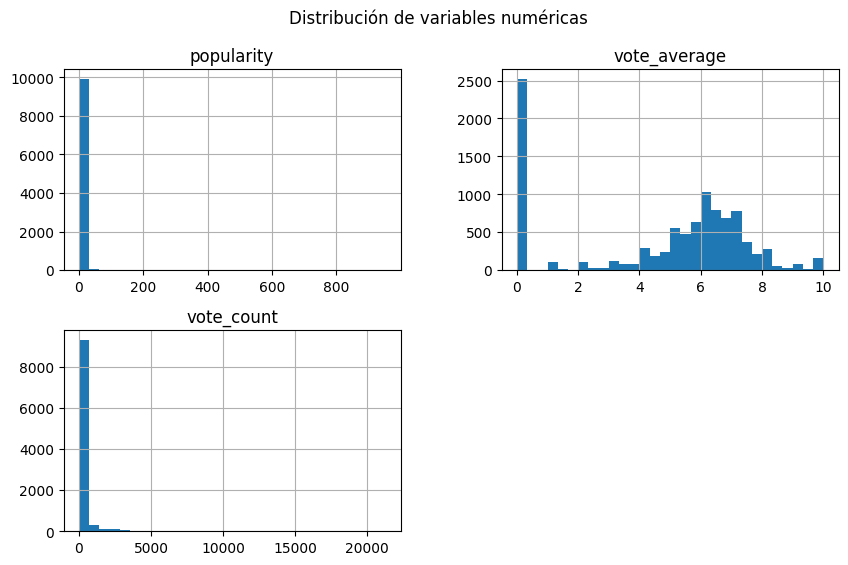

In [18]:
#distribución de variables numericas
num_cols = ['popularity', 'vote_average', 'vote_count']

df[num_cols].hist(bins=30, figsize=(10,6))
plt.suptitle("Distribución de variables numéricas")
plt.show()

In [19]:
#conteo por idioma
df['original_language'].value_counts().head(10)

original_language
en    5566
fr     545
ja     520
es     470
it     275
tl     245
de     222
ko     221
zh     184
hi     175
Name: count, dtype: int64

In [21]:
#Top 10 peliculas mas populares
df[['title','popularity']].sort_values(by='popularity', ascending=False).head(10)

,title,popularity
0,Frankenstein,951.3460
7,Playdate,388.3856
2,Predator: Badlands,314.6851
4,Code 3,251.8624
3,Black Phone 2,242.3412
6,War of the Worlds,204.4781
5,End of Loyalty,186.6110
8,Abyss,179.5906
10,Chainsaw Man - The Movie: Reze Arc,154.4678
9,Baramulla,148.1601


In [22]:
#top peliculas mejor calificadas
df[['title','vote_average']].sort_values(by='vote_average', ascending=False).head(10)

,title,vote_average
5010,When the house lights come on,10.0
4487,Third Grade,10.0
8251,Revue Starlight ―The LIVE Edel― Delight,10.0
8280,Family Affair,10.0
8271,Spy Capital,10.0
8226,Every Day,10.0
5946,Vika!,10.0
2242,Delivery Health,10.0
1947,Revue Starlight ―The STAGE Junior High― Rebellion,10.0
858,Oscar,10.0


Matriz de correlación

In [25]:
eda.matriz_correlacion()

,popularity,vote_average,vote_count
popularity,1.000000,0.170292,0.318279
vote_average,0.170292,1.000000,0.201036
vote_count,0.318279,0.201036,1.000000


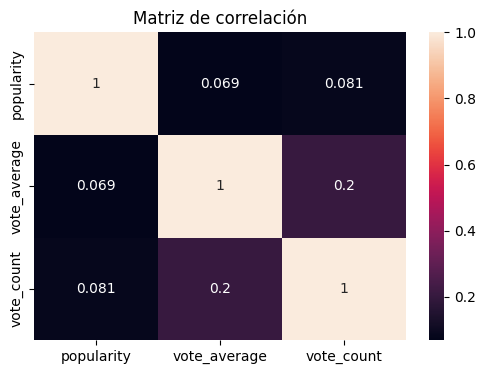

In [23]:
corr = df[['popularity','vote_average','vote_count']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

La mayoría de las películas presentan baja popularidad.

Existe relación entre cantidad de votos y popularidad.

La variable vote_count influye más que vote_average.

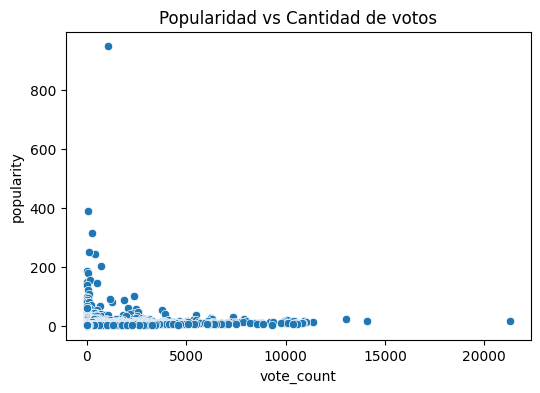

In [26]:
#relación entre popularidad vs votos
plt.figure(figsize=(6,4))
sns.scatterplot(x='vote_count', y='popularity', data=df)
plt.title("Popularidad vs Cantidad de votos")
plt.show()

### Guardamos el csv limpio en nuestra carpeta data en la subcarpeta processed usando la clase

---

In [28]:
eda.guardar_csv("../data/processed/tmdb_movies_clean.csv")